# Advanced Analytics & Risk Metrics

This notebook computes:

- Historical VaR (95%)
- Conditional VaR (CVaR)
- Rolling 90-Day Sharpe Ratio
- Investor Cohort Analysis
- SIP Continuity Analysis
- Sector HHI
- Fund Recommendation System

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import norm

# Display settings
pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

In [2]:
# Load datasets

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [3]:
print("NAV Shape:", nav.shape)
print("Transactions Shape:", transactions.shape)
print("Performance Shape:", performance.shape)
print("Holdings Shape:", holdings.shape)

NAV Shape: (46000, 3)
Transactions Shape: (32778, 13)
Performance Shape: (40, 19)
Holdings Shape: (322, 8)


In [4]:
nav.head()
transactions.head()
performance.head()
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [5]:
print(nav.columns.tolist())
print(transactions.columns.tolist())
print(performance.columns.tolist())
print(holdings.columns.tolist())

['amfi_code', 'date', 'nav']
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [6]:
# Convert to datetime

nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

In [7]:
nav.info()

transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investor_id         32778 non-null  object        
 1   transaction_date    32778 non-null  datetime64[ns]
 2   amfi_code           32778 non-null  int64         
 3   transaction_type    32778 non-null  object        
 4   amount_inr          32778 non-null  int64         
 5   state               32778 non-null  object        
 6   city                32778 

In [8]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)


In [9]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [10]:
nav["amfi_code"].unique()[:5]

array([100016, 100025, 100033, 101206, 101207])

In [ ]:
selected_funds = nav["amfi_code"].unique()[:5]

In [11]:
nav["rolling_sharpe"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(
           lambda x: (
               x.rolling(window=90).mean() /
               x.rolling(window=90).std()
           ) * np.sqrt(252)
       )
)

In [13]:
# Select first 5 unique AMFI codes
selected_funds = nav["amfi_code"].unique()[:5]

print(selected_funds)

[100016 100025 100033 101206 101207]


In [14]:
top5 = (
    performance
    .sort_values("aum_crore", ascending=False)
    .head(5)
)

selected_funds = top5["amfi_code"].tolist()

print(selected_funds)

[148568, 120842, 118634, 149322, 102886]


In [15]:
nav["rolling_sharpe"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(
           lambda x: (
               x.rolling(90).mean() /
               x.rolling(90).std()
           ) * np.sqrt(252)
       )
)

In [16]:
print(selected_funds)

[148568, 120842, 118634, 149322, 102886]


In [17]:
scheme_map = performance.set_index("amfi_code")["scheme_name"].to_dict()

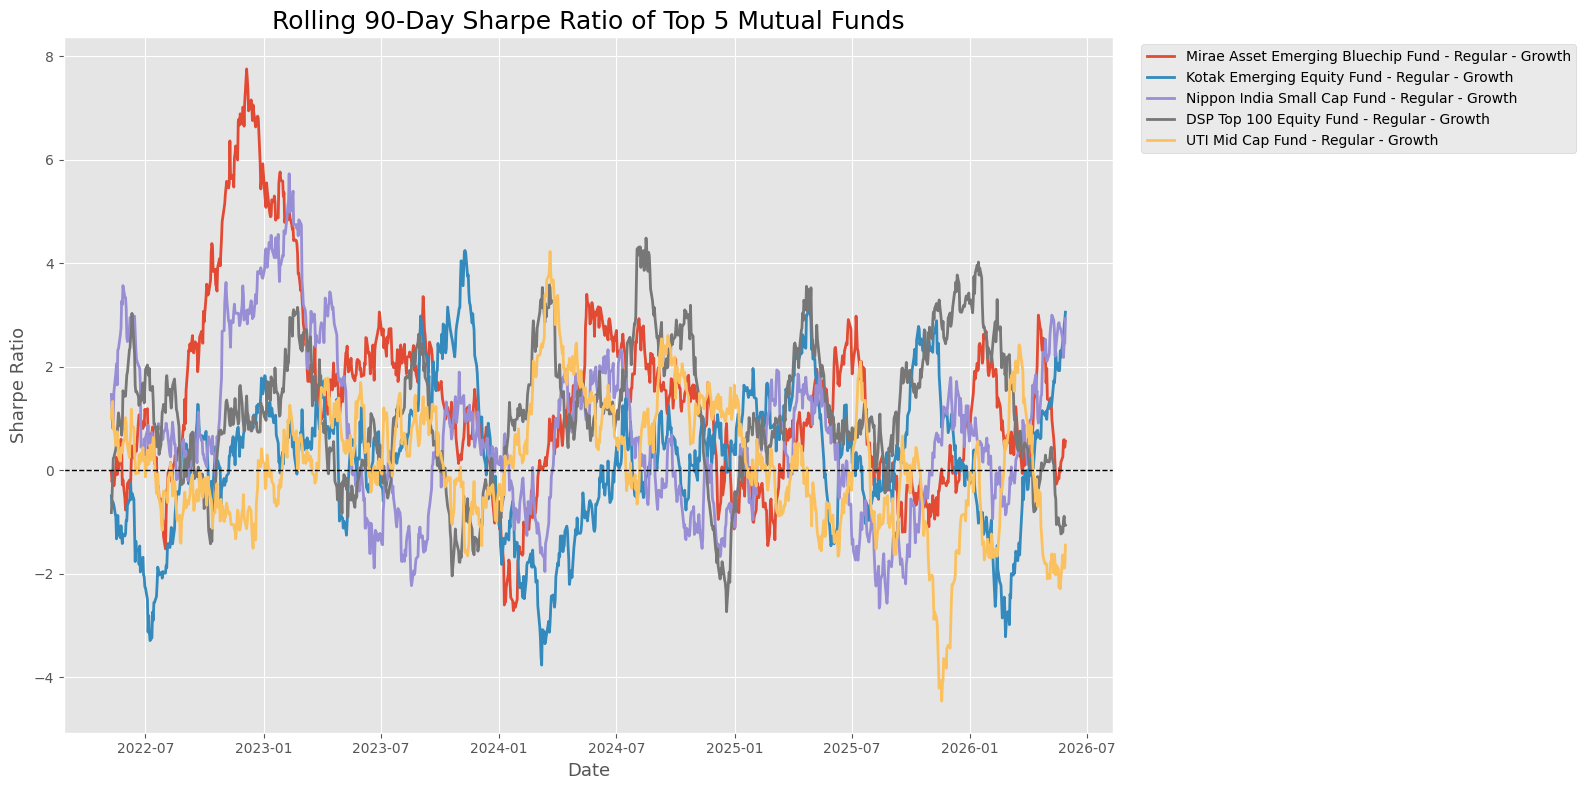

In [19]:
plt.figure(figsize=(16,8))

for fund in selected_funds:
    temp = nav[nav["amfi_code"] == fund]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        linewidth=2,
        label=scheme_map.get(fund)
    )

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title("Rolling 90-Day Sharpe Ratio of Top 5 Mutual Funds", fontsize=18)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Sharpe Ratio", fontsize=13)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("../charts/rolling_sharpe_chart.png", dpi=300)
plt.show()

In [20]:
# First investment date for each investor
cohort = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
)

# Add cohort year back to transactions
transactions["cohort_year"] = (
    transactions["investor_id"].map(cohort)
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED,2024
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING,2024
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING,2024


In [21]:
cohort_summary = (
    transactions.groupby("cohort_year")
    .agg(
        investors=("investor_id", "nunique"),
        avg_investment=("amount_inr", "mean"),
        total_investment=("amount_inr", "sum")
    )
    .reset_index()
)

cohort_summary

,cohort_year,investors,avg_investment,total_investment
0,2024,4803,107422.541832,3491125187
1,2025,197,109158.577061,30455243


In [22]:
top_fund = (
    transactions.groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [23]:
top_fund = top_fund.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top_fund

,cohort_year,amfi_code,count,scheme_name
0,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [24]:
cohort_report = cohort_summary.merge(
    top_fund[
        [
            "cohort_year",
            "scheme_name",
            "count"
        ]
    ],
    on="cohort_year",
    how="left"
)

cohort_report.rename(
    columns={
        "scheme_name": "favorite_fund",
        "count": "transactions_in_favorite_fund"
    },
    inplace=True
)

cohort_report

,cohort_year,investors,avg_investment,total_investment,favorite_fund,transactions_in_favorite_fund
0,2024,4803,107422.541832,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,197,109158.577061,30455243,SBI Small Cap Fund - Direct Plan - Growth,12


In [26]:
cohort_report.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

### Investor Cohort Analysis

- The 2024 cohort is significantly larger than the 2025 cohort, indicating that most investors entered during 2024.
- Investors in both cohorts invested approximately ₹1.08 lakh on average.
- The 2024 cohort invested a total of ₹349.11 Cr compared to ₹3.05 Cr in 2025.
- Mirae Asset Emerging Bluechip Fund was the most preferred fund among 2024 investors.
- SBI Small Cap Fund was the most preferred fund among the 2025 cohort.

In [27]:
# Count transactions for each investor
txn_count = (
    transactions.groupby("investor_id")
    .size()
    .reset_index(name="transaction_count")
)

# Keep investors with at least 6 transactions
eligible = txn_count[
    txn_count["transaction_count"] >= 6
]["investor_id"]

sip = transactions[
    transactions["investor_id"].isin(eligible)
].copy()

print("Eligible Investors:", sip["investor_id"].nunique())

Eligible Investors: 2950


In [28]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

In [29]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

In [30]:
gap_summary = (
    sip.groupby("investor_id")
       .agg(
           avg_gap_days=("gap_days", "mean"),
           transaction_count=("transaction_date", "count")
       )
       .reset_index()
)

gap_summary.head()

,investor_id,avg_gap_days,transaction_count
0,INV000002,82.800000,6
1,INV000004,53.375000,9
2,INV000005,52.000000,8
3,INV000006,99.000000,6
4,INV000008,50.285714,8


In [32]:
gap_summary["status"] = np.where(
    gap_summary["avg_gap_days"] > 35,
    "At Risk",
    "Regular"
)

gap_summary.head()

,investor_id,avg_gap_days,transaction_count,status
0,INV000002,82.800000,6,At Risk
1,INV000004,53.375000,9,At Risk
2,INV000005,52.000000,8,At Risk
3,INV000006,99.000000,6,At Risk
4,INV000008,50.285714,8,At Risk


In [33]:
gap_summary.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

### SIP Continuity Analysis

- Investors with an average SIP gap greater than 35 days are classified as **At Risk**.
- Large average gaps indicate irregular SIP investments and a higher probability of discontinuing investments.
- This analysis can help mutual fund houses identify investors who may require engagement or reminders.

In [34]:
hhi = (
    holdings.groupby("amfi_code")["weight_pct"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,1395.3386
1,100033,1475.9226
2,101206,1293.3173
3,101207,2007.0043
4,102885,1747.0902


In [35]:
hhi = hhi.merge(
    performance[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name,fund_house
0,100016,1395.3386,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100033,1475.9226,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
2,101206,1293.3173,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund


In [36]:
def classify_hhi(value):
    if value < 1000:
        return "Highly Diversified"
    elif value < 1800:
        return "Moderately Concentrated"
    else:
        return "Highly Concentrated"

hhi["portfolio_type"] = hhi["HHI"].apply(classify_hhi)

hhi.head()

,amfi_code,HHI,scheme_name,fund_house,portfolio_type
0,100016,1395.3386,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderately Concentrated
1,100033,1475.9226,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Moderately Concentrated
2,101206,1293.3173,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Moderately Concentrated
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Highly Concentrated
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Moderately Concentrated


In [37]:
hhi.to_csv("../reports/hhi_report.csv", index=False)

# Advanced Analytics Summary

In [1]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd().parent

performance = pd.read_csv(
    BASE_DIR / "data" / "processed" / "scheme_performance_cleaned.csv"
)

transactions = pd.read_csv(
    BASE_DIR / "data" / "processed" / "investor_transactions_cleaned.csv"
)

sector_hhi = pd.read_csv(
    BASE_DIR / "data" / "processed" / "sector_hhi.csv"
)

print("Performance columns:")
print(performance.columns.tolist())

print("\nTransaction columns:")
print(transactions.columns.tolist())

print("\nSector HHI columns:")
print(sector_hhi.columns.tolist())

Performance columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Transaction columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Sector HHI columns:
['amfi_code', 'scheme_name', 'fund_house', 'sector_hhi', 'concentration_level']


In [5]:
# ============================================================
# ADVANCED ANALYTICS SUMMARY - 5 KEY INSIGHTS
# ============================================================

# 1. Best risk-adjusted fund
best_sharpe = performance.loc[
    performance["sharpe_ratio"].idxmax()
]

print("1. BEST RISK-ADJUSTED FUND")
print("Fund:", best_sharpe["scheme_name"])
print("Sharpe Ratio:", best_sharpe["sharpe_ratio"])
print("3-Year Return:", best_sharpe["return_3yr_pct"], "%")


# ------------------------------------------------------------

# 2. Highest return fund
best_return = performance.loc[
    performance["return_3yr_pct"].idxmax()
]

print("\n2. HIGHEST 3-YEAR RETURN")
print("Fund:", best_return["scheme_name"])
print("3-Year Return:", best_return["return_3yr_pct"], "%")
print("Risk Grade:", best_return["risk_grade"])


# ------------------------------------------------------------

# 3. Highest sector concentration
highest_hhi = sector_hhi.loc[
    sector_hhi["sector_hhi"].idxmax()
]

print("\n3. HIGHEST SECTOR CONCENTRATION")
print("Fund:", highest_hhi["scheme_name"])
print("Sector HHI:", round(highest_hhi["sector_hhi"], 2))
print(
    "Concentration Level:",
    highest_hhi["concentration_level"]
)


# ------------------------------------------------------------

# 4. Investor age group with highest average investment
age_investment = (
    transactions
    .groupby("age_group")["amount_inr"]
    .mean()
    .sort_values(ascending=False)
)

top_age_group = age_investment.index[0]
top_age_amount = age_investment.iloc[0]

print("\n4. HIGHEST AVERAGE INVESTMENT BY AGE GROUP")
print("Age Group:", top_age_group)
print("Average Transaction Amount: ₹", round(top_age_amount, 2))


# ------------------------------------------------------------

# 5. State with highest total investment
state_investment = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

top_state = state_investment.index[0]
top_state_amount = state_investment.iloc[0]

print("\n5. HIGHEST INVESTMENT BY STATE")
print("State:", top_state)
print("Total Transaction Amount: ₹", round(top_state_amount, 2))


1. BEST RISK-ADJUSTED FUND
Fund: ICICI Pru Liquid Fund - Regular - Growth
Sharpe Ratio: 7.68
3-Year Return: 7.68 %

2. HIGHEST 3-YEAR RETURN
Fund: SBI Small Cap Fund - Regular Plan - Growth
3-Year Return: 23.39 %
Risk Grade: Very High

3. HIGHEST SECTOR CONCENTRATION
Fund: Axis Bluechip Fund - Regular - Growth
Sector HHI: 2967.69
Concentration Level: Highly Concentrated

4. HIGHEST AVERAGE INVESTMENT BY AGE GROUP
Age Group: 18-25
Average Transaction Amount: ₹ 108144.71

5. HIGHEST INVESTMENT BY STATE
State: Punjab
Total Transaction Amount: ₹ 315780459


# Advanced Analytics Summary — Key Insights

## 1. ICICI Pru Liquid Fund delivered the strongest risk-adjusted performance

ICICI Pru Liquid Fund - Regular - Growth recorded the highest Sharpe ratio of **7.68**, with a 3-year return of **7.68%**. This indicates the strongest return per unit of risk among the funds analysed. As a liquid fund typically experiences lower volatility than equity funds, its high Sharpe ratio highlights strong risk-adjusted consistency rather than the highest absolute return.

## 2. SBI Small Cap Fund achieved the highest 3-year return

SBI Small Cap Fund - Regular Plan - Growth generated the highest 3-year return of **23.39%**. The fund carries a **Very High** risk grade, showing the trade-off between higher return potential and greater investment risk.

## 3. Axis Bluechip Fund showed the highest sector concentration

Axis Bluechip Fund - Regular - Growth recorded the highest sector HHI of **2967.69** and was classified as **Highly Concentrated**. This indicates that a relatively large portion of its portfolio is concentrated in fewer sectors, creating greater sector-specific exposure.

## 4. Investors aged 18–25 had the highest average transaction amount

The **18–25** age group recorded the highest average transaction amount of approximately **₹108,144.71**. In this dataset, younger investors therefore showed the highest average transaction size among the analysed age groups.

## 5. Punjab recorded the highest total transaction value

Punjab contributed the highest total transaction value of **₹315,780,459**, approximately **₹31.58 crore**. This makes Punjab the leading state by aggregate transaction value in the analysed investor dataset.

## Overall Conclusion

The advanced analytics reveal an important risk-return trade-off across the mutual fund universe. The strongest risk-adjusted performer was different from the highest absolute-return fund, while sector HHI analysis identified portfolio concentration risk that return metrics alone cannot capture. Investor analysis also revealed distinct demographic and geographic patterns in transaction behaviour.